In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.signal
from scipy import *
import copy

from rich import print

In [128]:
def ejes():
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(alpha=0.5)
    plt.tight_layout()

In [129]:
# Constants
PATH = "../@data/roz.csv"

In [130]:
df0 = pd.read_csv(PATH, sep="\t", header=0)
df0.head()

,ts,Sample#,A,B,dx,F
0,254451622.0,0.0,-43.75692,-29.44337,15.27346,0.09157
1,254451640.0,1.0,-43.76684,-29.44833,15.41719,0.08699
2,254451656.0,2.0,-43.71970,-29.43593,15.42845,0.08699
3,254451715.0,3.0,-43.75940,-29.46074,15.43485,0.08852
4,254451732.0,4.0,-43.70481,-29.45578,15.42967,0.08699


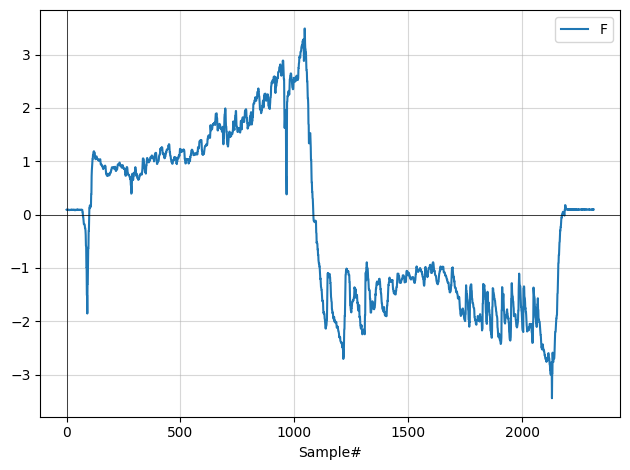

In [131]:
df0.plot(x="Sample#", y="F")
ejes()

In [132]:
# Agregar columna de tiempo al data set
srate = 10
tsig = df0["Sample#"] / srate
df1 = df0.copy()
df1["t"] = tsig

df1.head()

,ts,Sample#,A,B,dx,F,t
0,254451622.0,0.0,-43.75692,-29.44337,15.27346,0.09157,0.0
1,254451640.0,1.0,-43.76684,-29.44833,15.41719,0.08699,0.1
2,254451656.0,2.0,-43.71970,-29.43593,15.42845,0.08699,0.2
3,254451715.0,3.0,-43.75940,-29.46074,15.43485,0.08852,0.3
4,254451732.0,4.0,-43.70481,-29.45578,15.42967,0.08699,0.4


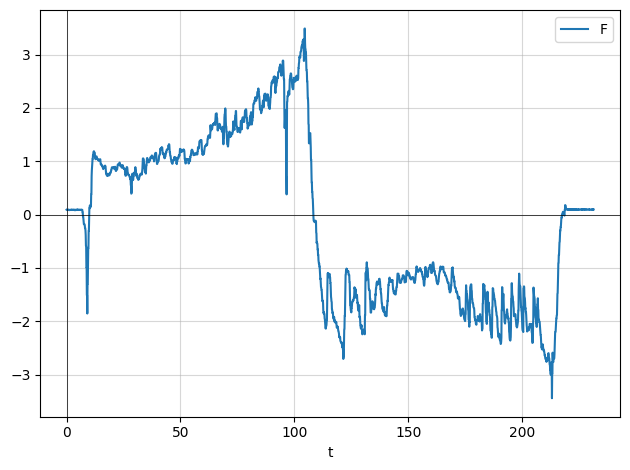

In [133]:
df1.plot(x="t", y="F")
ejes()

In [134]:
tsig = np.array(df1["t"])
sig = np.array(df1["F"])
n = len(sig)
print(f"{n=}")

k = 80
ws = np.arange(-k, k+1)
tgauss = ws / srate
print(f'{tgauss=}')

n=2315

tgauss=array([-8. , -7.9, -7.8, -7.7, -7.6, -7.5, -7.4, -7.3, -7.2, -7.1, -7. ,
       -6.9, -6.8, -6.7, -6.6, -6.5, -6.4, -6.3, -6.2, -6.1, -6. , -5.9,
       -5.8, -5.7, -5.6, -5.5, -5.4, -5.3, -5.2, -5.1, -5. , -4.9, -4.8,
       -4.7, -4.6, -4.5, -4.4, -4.3, -4.2, -4.1, -4. , -3.9, -3.8, -3.7,
       -3.6, -3.5, -3.4, -3.3, -3.2, -3.1, -3. , -2.9, -2.8, -2.7, -2.6,
       -2.5, -2.4, -2.3, -2.2, -2.1, -2. , -1.9, -1.8, -1.7, -1.6, -1.5,
       -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4,
       -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,
        0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,
        1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,
        3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,
        4.1,  4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,
        5.2,  5.3,  5.4,  5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,
        6.3,  6.4,  6.5,  6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,
        7.4,  7.5,  7.6,  7.7,  7.8,  7.9,  8. ])

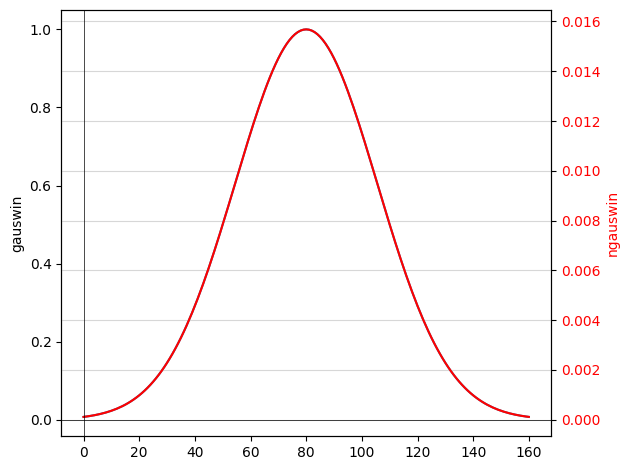

In [135]:
fwhm = 6

gauswin = np.exp(-(4 * np.log(2) * tgauss ** 2) / fwhm ** 2)

ngauswin = gauswin / np.sum(gauswin)

plt.plot(gauswin)
plt.ylabel('gauswin')
ax2 = plt.twinx()
ax2.plot(ngauswin, 'r') # type: ignore
ax2.set_ylabel('ngauswin', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ejes()

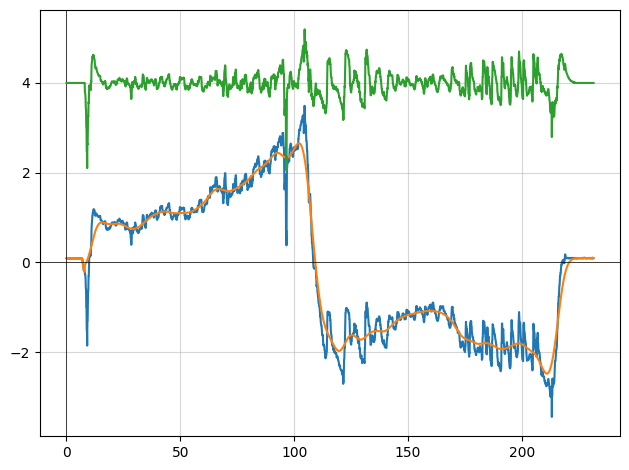

In [144]:
# apply the filter
fsig = sig.copy()

for i in range(k+1, n-k):
    fsig[i] = np.sum(sig[i-k : i+k+1]*ngauswin)
    
plt.plot(tsig, sig)
plt.plot(tsig, fsig)
ejes()

plt.plot(tsig, sig-fsig + 4)